VaR_0.95  = 0.0882
CVaR_0.95 = 0.1042


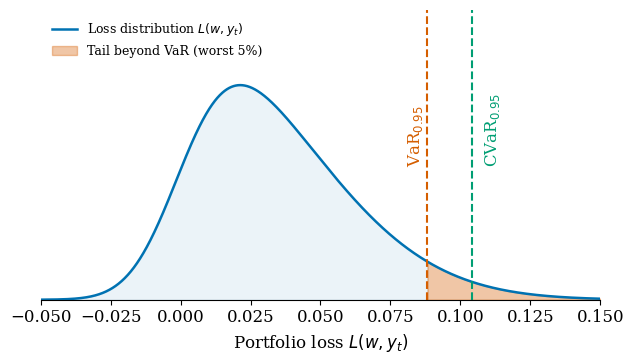

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

COLOR_MAIN = "#0072B2"   
COLOR_TAIL = "#D55E00"   
COLOR_CVAR = "#009E73"   

loc, scale = 0.0, 0.045
dist = stats.skewnorm(a_skew, loc=loc, scale=scale)

x = np.linspace(-0.05, 0.15, 2000)
pdf = dist.pdf(x)

alpha = 0.95
var_alpha = dist.ppf(alpha)

tail_x = np.linspace(var_alpha, x[-1], 2000)
tail_pdf = dist.pdf(tail_x)
try:
    trapz = np.trapezoid
except AttributeError:
    trapz = np.trapz
cvar_alpha = trapz(tail_x * tail_pdf, tail_x) / trapz(tail_pdf, tail_x)

print(f"VaR_{alpha}  = {var_alpha:.4f}")
print(f"CVaR_{alpha} = {cvar_alpha:.4f}")
assert cvar_alpha > var_alpha, "CVaR must exceed VaR at the same confidence level"


fig, ax = plt.subplots(figsize=(6.5, 3.8))

ax.plot(x, pdf, color=COLOR_MAIN, lw=1.8, label="Loss distribution $L(w, y_t)$")
ax.fill_between(x, pdf, where=(x < var_alpha), color=COLOR_MAIN, alpha=0.08)

mask_tail = x >= var_alpha
tail_pct = int(round((1 - alpha) * 100))
ax.fill_between(x, pdf, where=mask_tail, color=COLOR_TAIL, alpha=0.35,
                 label=f"Tail beyond VaR (worst {tail_pct}%)")

ax.axvline(var_alpha, color=COLOR_TAIL, lw=1.5, ls="--")
ax.axvline(cvar_alpha, color=COLOR_CVAR, lw=1.5, ls="--")

ymax = pdf.max() * 1.35
ax.set_ylim(0, ymax)
ax.set_xlim(x[0], x[-1])

label_y = pdf.max() * 0.62
ax.text(var_alpha - 0.001, label_y, fr"VaR$_{{{alpha}}}$", color=COLOR_TAIL,
         ha="right", va="bottom", fontsize=12, rotation=90)
ax.text(cvar_alpha + 0.004, label_y, fr"CVaR$_{{{alpha}}}$", color=COLOR_CVAR,
         ha="left", va="bottom", fontsize=12, rotation=90)

ax.set_xlabel("Portfolio loss $L(w, y_t)$")
# ax.set_ylabel("Density")
ax.legend(loc="upper left", frameon=False, fontsize=9)

ax.set_yticks([])
ax.spines["left"].set_visible(False)
# ax.set_ylabel("")

fig.tight_layout()
fig.savefig("figures/var_cvar.pdf", bbox_inches="tight")
# fig.savefig("figures/var_cvar.png", dpi=200, bbox_inches="tight")
plt.show()